In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [106]:
# Load dataset
data = pd.read_csv('Social_Network_Ads.csv')

In [107]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [108]:
# Select features and target
X = data[['Age', 'EstimatedSalary']].values
y = data['Purchased'].values

In [109]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [110]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [111]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [112]:
def compute_cost(X, y, w, b):
    m = len(y)
    z = np.dot(X, w) + b
    h = sigmoid(z)
    
    cost = (-1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost


In [113]:
def compute_gradient(X, y, w, b):
    m = len(y)
    z = np.dot(X, w) + b
    h = sigmoid(z)
    
    dw = (1/m) * np.dot(X.T, (h - y))
    db = (1/m) * np.sum(h - y)
    
    return dw, db

In [114]:
def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []
    
    for i in range(iterations):
        dw, db = compute_gradient(X, y, w, b)
        
        w = w - alpha * dw
        b = b - alpha * db
        
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")
    
    return w, b, cost_history

In [115]:
# Initialize parameters
w = np.zeros(X_train.shape[1])
b = 0

# Train model
w, b, cost_history = gradient_descent(X_train, y_train, w, b, alpha=0.01, iterations=1000)

Iteration 0, Cost: 0.6918663522586193
Iteration 100, Cost: 0.5938586134768598
Iteration 200, Cost: 0.535766742358238
Iteration 300, Cost: 0.49899206159229403
Iteration 400, Cost: 0.47420210549561886
Iteration 500, Cost: 0.4566150199061656
Iteration 600, Cost: 0.4436269131219063
Iteration 700, Cost: 0.4337270308836365
Iteration 800, Cost: 0.42598813853419726
Iteration 900, Cost: 0.4198133211017271


In [116]:
def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    return [1 if i > 0.5 else 0 for i in probs]

y_pred_manual = predict(X_test, w, b)

y_pred_manual

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1]

In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_manual)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

Confusion Matrix:
 [[57  1]
 [ 5 17]]
TP: 17
FP: 1
TN: 57
FN: 5


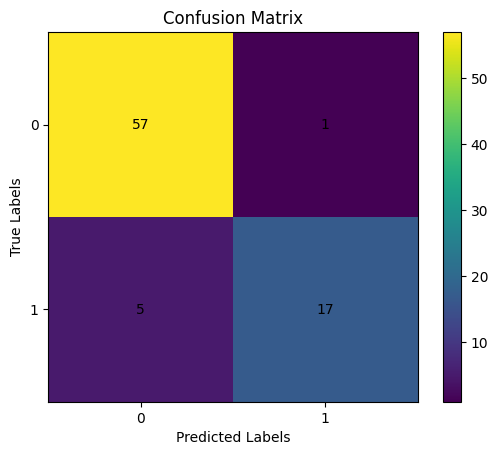

In [118]:
import matplotlib.pyplot as plt

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.xticks([0, 1])
plt.yticks([0, 1])

# Add values inside the matrix
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

In [119]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.925
Error Rate: 0.07499999999999996
Precision: 0.9444444444444444
Recall: 0.7727272727272727


In [120]:
from sklearn.linear_model import LogisticRegression

In [121]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [122]:
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1]


In [123]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

Confusion Matrix:
 [[57  1]
 [ 5 17]]
TP: 17
FP: 1
TN: 57
FN: 5


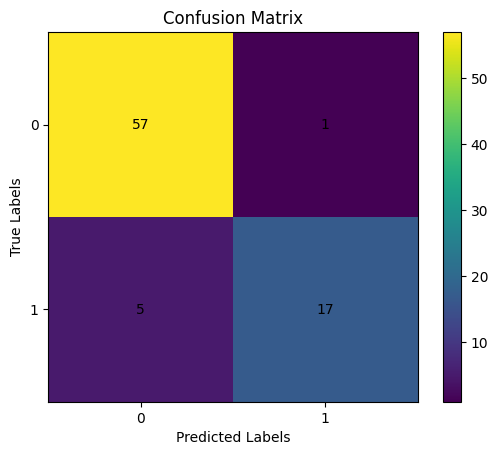

In [124]:
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.xticks([0, 1])
plt.yticks([0, 1])

# Add values inside the matrix
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

In [125]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.925
Error Rate: 0.07499999999999996
Precision: 0.9444444444444444
Recall: 0.7727272727272727
